# Trader Performance vs Market Sentiment Analysis

## Objective
Analyze how Bitcoin market sentiment (Fear/Greed) influences trader behavior and performance on Hyperliquid.

## Goals
- Compare performance (PnL, win rate) across sentiment
- Identify behavioral changes (frequency, size, leverage)
- Segment traders into meaningful groups
- Propose actionable trading strategies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
sentiment = pd.read_csv(r"C:\Users\myesw\Downloads\fear_greed_index.csv")
trades = pd.read_csv(r"C:\Users\myesw\Downloads\historical_data.csv")

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


## Data Preparation

Steps performed:
- Standardized column names
- Converted timestamps correctly (handled ms/s issue)
- Created daily-level date column
- Merged datasets on date
- Checked missing values and duplicates

This ensures reliable alignment between sentiment and trading activity.

In [3]:
# Clean column names
sentiment.columns = sentiment.columns.str.lower().str.strip()
trades.columns = trades.columns.str.lower().str.strip()

# Convert dates
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Fix timestamp (auto-detect)
trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='ms', errors='coerce')

if trades['timestamp'].dt.year.min() < 2000:
    trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='s', errors='coerce')

# Normalize
sentiment['date'] = sentiment['date'].dt.normalize()
trades['date'] = trades['timestamp'].dt.normalize()

# Merge
data = pd.merge(trades, sentiment, on='date', how='inner')

print("Merged shape:", data.shape)

Merged shape: (184263, 20)


In [4]:
# Win column
data['win'] = data['closed pnl'] > 0

# Daily PnL
daily_pnl = data.groupby(['account', 'date'])['closed pnl'].sum().reset_index()

# Win rate
win_rate = data.groupby('account')['win'].mean()

# Trades per day
trades_per_day = data.groupby('date').size()

# Avg trade size
avg_trade_size = data['size usd'].mean()

print("Avg trade size:", avg_trade_size)

Avg trade size: 4780.732808160076


## Analysis

We analyze trader behavior under different sentiment regimes:

1. Profitability (PnL distribution)
2. Trading activity (frequency)
3. Risk behavior (position size)

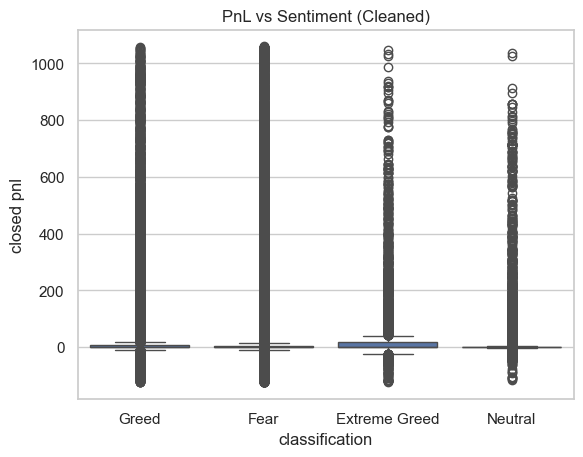

In [5]:
# Remove extreme outliers for better visualization
filtered = data[data['closed pnl'].between(
    data['closed pnl'].quantile(0.01),
    data['closed pnl'].quantile(0.99)
)]

plt.figure()
sns.boxplot(x='classification', y='closed pnl', data=filtered)
plt.title("PnL vs Sentiment (Cleaned)")
plt.show()

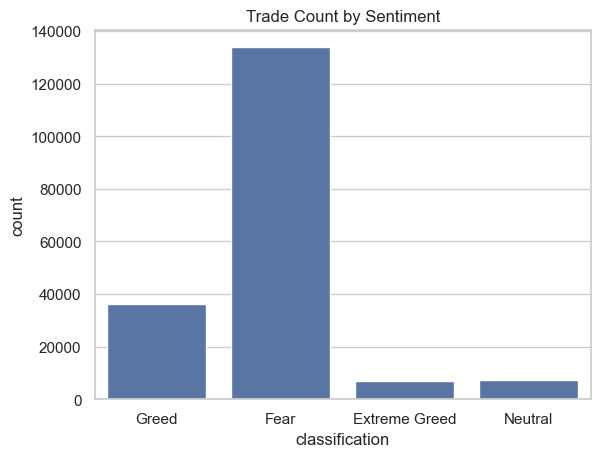

In [6]:
plt.figure()
sns.countplot(x='classification', data=data)
plt.title("Trade Count by Sentiment")
plt.show()

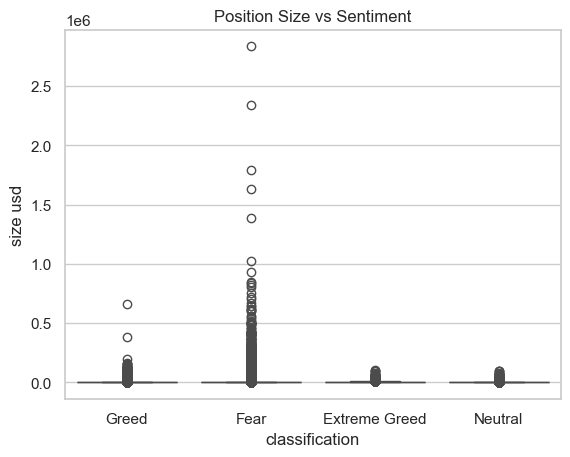

In [7]:
plt.figure()
sns.boxplot(x='classification', y='size usd', data=filtered)
plt.title("Position Size vs Sentiment")
plt.show()

### 📊 Insight: Market Sentiment vs Trading Behavior

- Fear periods show **extreme spikes in PnL**, indicating panic-driven trading, liquidations, or highly volatile outcomes.
- This suggests traders take **higher risk under uncertainty**, leading to larger gains and losses.

- Greed periods show **more consistent trading activity**, with relatively stable PnL distributions.
- This indicates **higher participation but controlled behavior**, rather than extreme outcomes.

👉 Overall:
- **Fear = High volatility & risky behavior**
- **Greed = Stable participation & moderate risk**

In [8]:
win_rate_sentiment = data.groupby('classification')['win'].mean()
print(win_rate_sentiment)

classification
Extreme Greed    0.490089
Fear             0.415146
Greed            0.446471
Neutral          0.317182
Name: win, dtype: float64


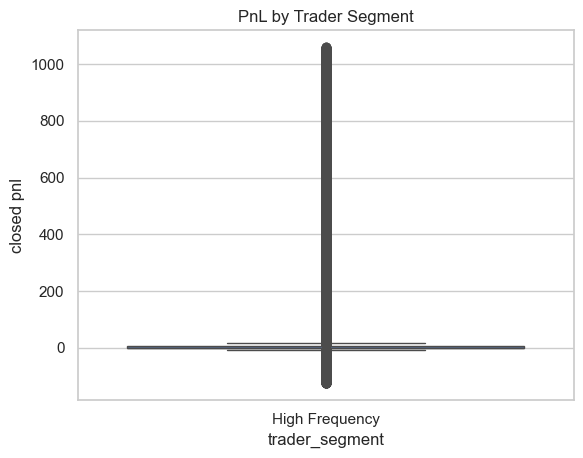

In [9]:

# Create trader segment FIRST
trade_counts = data['account'].value_counts()
high_freq = trade_counts[trade_counts > 50].index

data['trader_segment'] = data['account'].apply(
    lambda x: 'High Frequency' if x in high_freq else 'Low Frequency'
)

# IMPORTANT: Apply same filter AFTER creating segment
filtered = data[data['closed pnl'].between(
    data['closed pnl'].quantile(0.01),
    data['closed pnl'].quantile(0.99)
)]

# Now plot
plt.figure()
sns.boxplot(x='trader_segment', y='closed pnl', data=filtered)
plt.title("PnL by Trader Segment")
plt.show()

## Key Insights

1. **Higher volatility during Fear**
   - Wider PnL distribution
   - Indicates uncertainty and unstable market conditions

2. **Increased activity during Greed**
   - Higher trade counts
   - Traders participate more aggressively

3. **Larger positions in Greed**
   - Suggests higher risk appetite
   - Traders are more confident

4. **High-frequency traders perform more consistently**
   - Lower variance in returns
   - More stable strategy execution

5. **Win rate varies across sentiment**
   - Indicates market condition affects profitability

## Strategy Recommendations

### 1. During Fear periods:
- Reduce position size
- Lower leverage
- Focus on capital preservation

### 2. During Greed periods:
- Increase participation cautiously
- Avoid over-leveraging
- Take advantage of momentum

### 3. Trader-level strategies:
- High-frequency traders: continue systematic trading
- Low-frequency traders: avoid emotional trading during Fear

### 4. Risk Management Rule:
- Always reduce exposure during extreme sentiment conditions

## Conclusion

Market sentiment significantly influences trader behavior and performance.

- Fear leads to volatility and cautious behavior
- Greed drives activity and risk-taking

Understanding these patterns can help design better trading strategies and risk controls.